In [186]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import photutils.isophote as isoph
import photutils.centroids as cen
from photutils.aperture import EllipticalAperture
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy.ndimage import rotate,zoom,shift
from cmath import polar,rect
from scipy.optimize import curve_fit,newton
from scipy.integrate import quad,simpson
import pandas as pd

## 1

In [202]:
NGC2403_g = fits.open('NGC_2403_SDSS_g_bms2014.fits')
#NGC2403_g = fits.open('NGC_2403_I_g_fgg1996.fits')

In [203]:
image_g = NGC2403_g[0].data
center = cen.centroid_2dg(image_g)

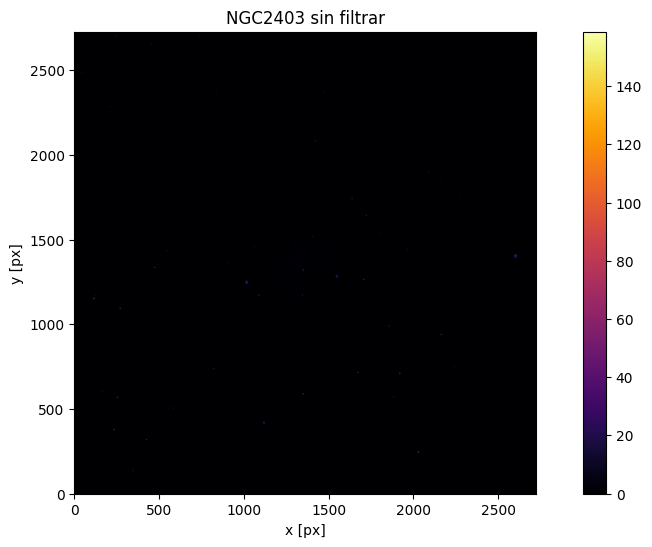

In [189]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.set(title='NGC2403 sin filtrar',xlabel='x [px]',ylabel='y [px]')
fig.colorbar(im)
plt.savefig('fig1.png')
plt.show()

/tmp/ipykernel_12422/1965382501.py:1: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(image_g.reshape(2727**2))


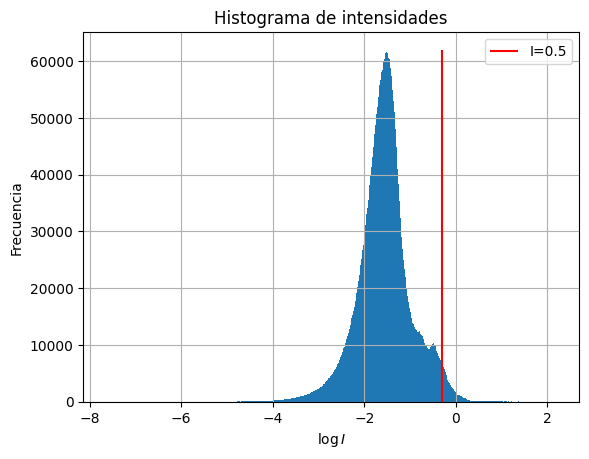

In [190]:
data_hist = np.log10(image_g.reshape(2727**2))
n_bins = 1000

fig, ax = plt.subplots()
hist = ax.hist(data_hist,n_bins)
ax.vlines(np.log10(0.5),0,62000,'r',label='I=0.5')
ax.set(title='Histograma de intensidades',xlabel=r'$\log I$',ylabel='Frecuencia')
ax.grid()
ax.legend()
plt.savefig('hist.png')
plt.show()

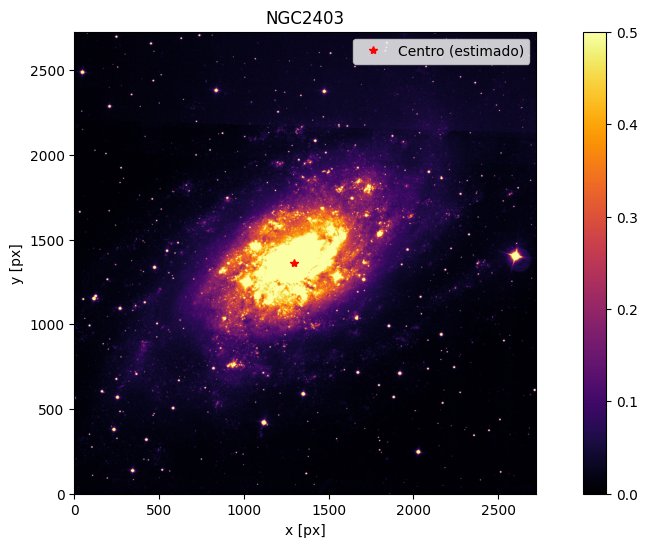

In [191]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax.plot(center[0],center[1],'r*',label = 'Centro (estimado)')
ax.set(title='NGC2403',xlabel='x [px]',ylabel='y [px]')
fig.colorbar(im)
ax.legend()
plt.savefig('fig2.png')
plt.show()

In [204]:
cond0 = image_g>=0.35
cond = cond0[900:1900,700:1800]

dist = np.zeros_like(cond0)
dist[900:1900,700:1800] = cond

In [205]:
xx = np.arange(cond0.shape[0])
yy = np.arange(cond0.shape[0])

XX,YY = np.meshgrid(xx,yy)

xs_dist = XX[dist]
ys_dist = YY[dist]

In [206]:
cov = np.cov(xs_dist,ys_dist)
eigvals, eigvecs = np.linalg.eigh(cov)  # eigh porque la covarianza es simétrica

# Ordenar de mayor a menor
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

angle = np.arctan(eigvecs[1,0]/eigvecs[0,0])

sma = 3*eigvals[0]**0.5
eps = 1 - eigvals[1]/eigvals[0]

In [207]:
geometry = isoph.EllipseGeometry(x0=center[0], y0=center[1], sma=sma, eps=eps,
                           pa=angle)

In [208]:
geometry.x0,geometry.y0,geometry.sma,geometry.eps,geometry.pa

(1298.5301191873345,
 1359.8957495793572,
 601.0753892700169,
 0.5837362458159074,
 0.6081633670416176)

In [209]:
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          geometry.pa)

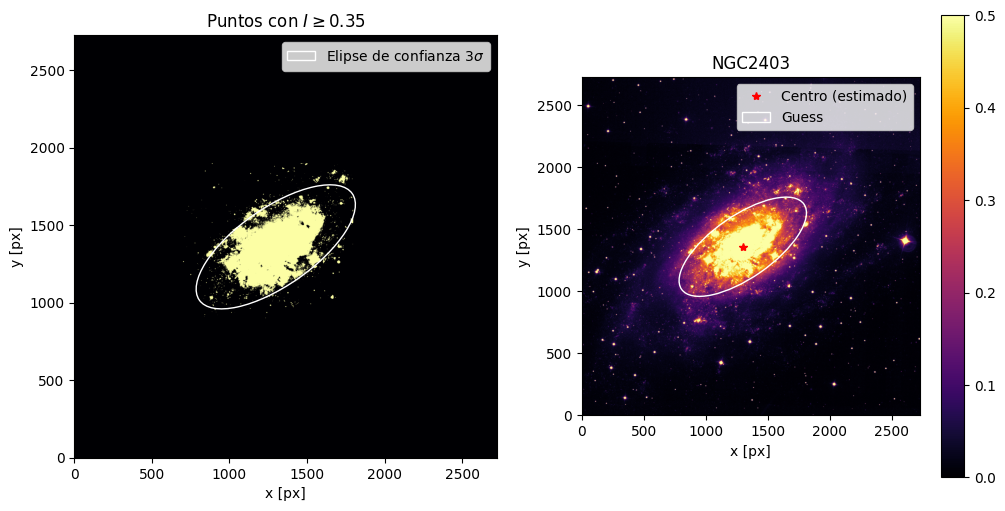

In [198]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(dist,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
#ax.plot(center[0],center[1],'r*')
aper.plot(ax[0],color='white',label=r'Elipse de confianza $3\sigma$')
im = ax[1].imshow(image_g,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax[1].plot(center[0],center[1],'r*',label='Centro (estimado)')
aper.plot(color='white',label='Guess')
ax[0].set(title=r'Puntos con $I\geq 0.35$',xlabel='x [px]',ylabel='y [px]')
ax[1].set(title=r'NGC2403',xlabel='x [px]',ylabel='y [px]')
ax[0].legend()
ax[1].legend()
fig.colorbar(im)
plt.savefig('fig3.png')
plt.show()

In [210]:
np.random.seed(1)
for i in range(image_g.shape[0]):
    for j in range(image_g.shape[1]):
        if image_g[i,j]>0.5:
            image_g[i,j]=0.5+1e-7*np.random.random()
        elif image_g[i,j]<0.0:
            image_g[i,j]=1e-7*np.random.random()


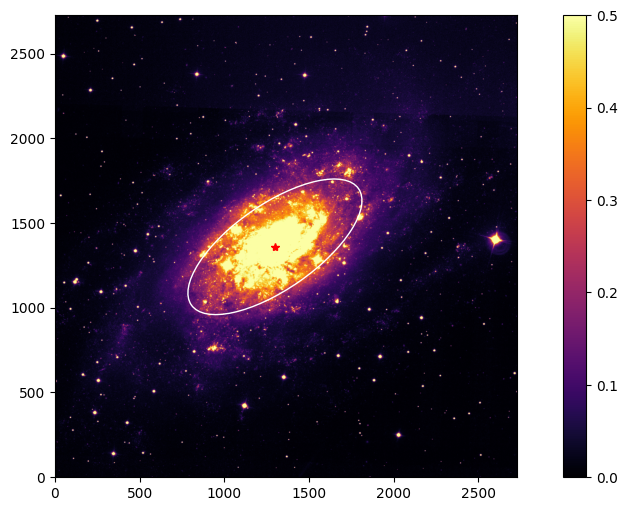

In [200]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.plot(center[0],center[1],'r*')
aper.plot(color='white')
fig.colorbar(im)
plt.show()

In [211]:
ellipse = isoph.Ellipse(image_g,geometry)
isolist = ellipse.fit_image()

In [17]:
for i in isolist:
    print(i.eps)

0.0
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.95
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4840456357489339
0.4389759271788979
0.4840456357489339
0.6264418908622568
0.6

In [161]:
isogeom = []
isoaper = []
for iso in isolist[1:]:
    isogeom.append(isoph.EllipseGeometry(x0=iso.x0, y0=iso.y0, sma=iso.sma, eps=iso.eps,
                           pa=iso.pa))
    
for geom in isogeom:
    isoaper.append(EllipticalAperture((geom.x0, geom.y0), geom.sma, geom.sma * (1 - geom.eps), geom.pa))

In [162]:
isogeom[-1].sma

1886.432058233644

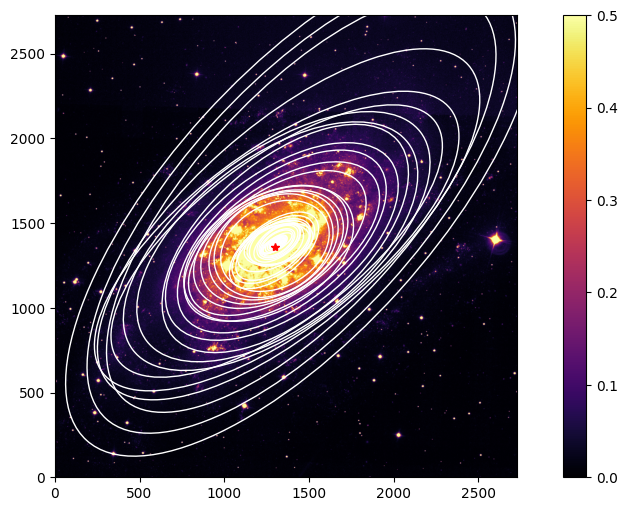

In [20]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')
ax.plot(center[0],center[1],'r*')
#aper.plot(color='white')
for i in range(0,len(isoaper)):
    isoaper[i].plot(color='white')
fig.colorbar(im)
plt.xlim(0,2727)
plt.ylim(0,2727)
plt.show()

In [212]:
eps_mean = np.mean(isolist.eps)
pa_mean = np.mean(isolist.pa)
x0_mean = np.mean(isolist.x0)
y0_mean = np.mean(isolist.y0)


In [214]:
print(f'{x0_mean}+-{np.std(isolist.x0)},{y0_mean}+-{np.std(isolist.y0)}')

1316.2297769095487+-29.757526148670504,1389.0265221091902+-45.80981602166382


In [213]:
x0_mean,y0_mean

(1316.2297769095487, 1389.0265221091902)

In [22]:
mask = isolist.ellip_err==isolist.ellip_err.max()
index = np.arange(0,len(isolist))
index[mask]

array([20])

In [23]:
isolist[7].to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_error,grad_rerror,x0,x0_err,y0,y0_err,ndata,nflag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
0.9209294379103524,0.5000000527278787,6.8872183766164305e-09,0.4840456357489339,0.037521400582341345,34.84519418595028,1.6103109296498717,-1.2666739964723119e-07,None,None,1313.012047513746,0.02676526557263421,1382.6970969051965,0.021500731213906648,13,0,1,5


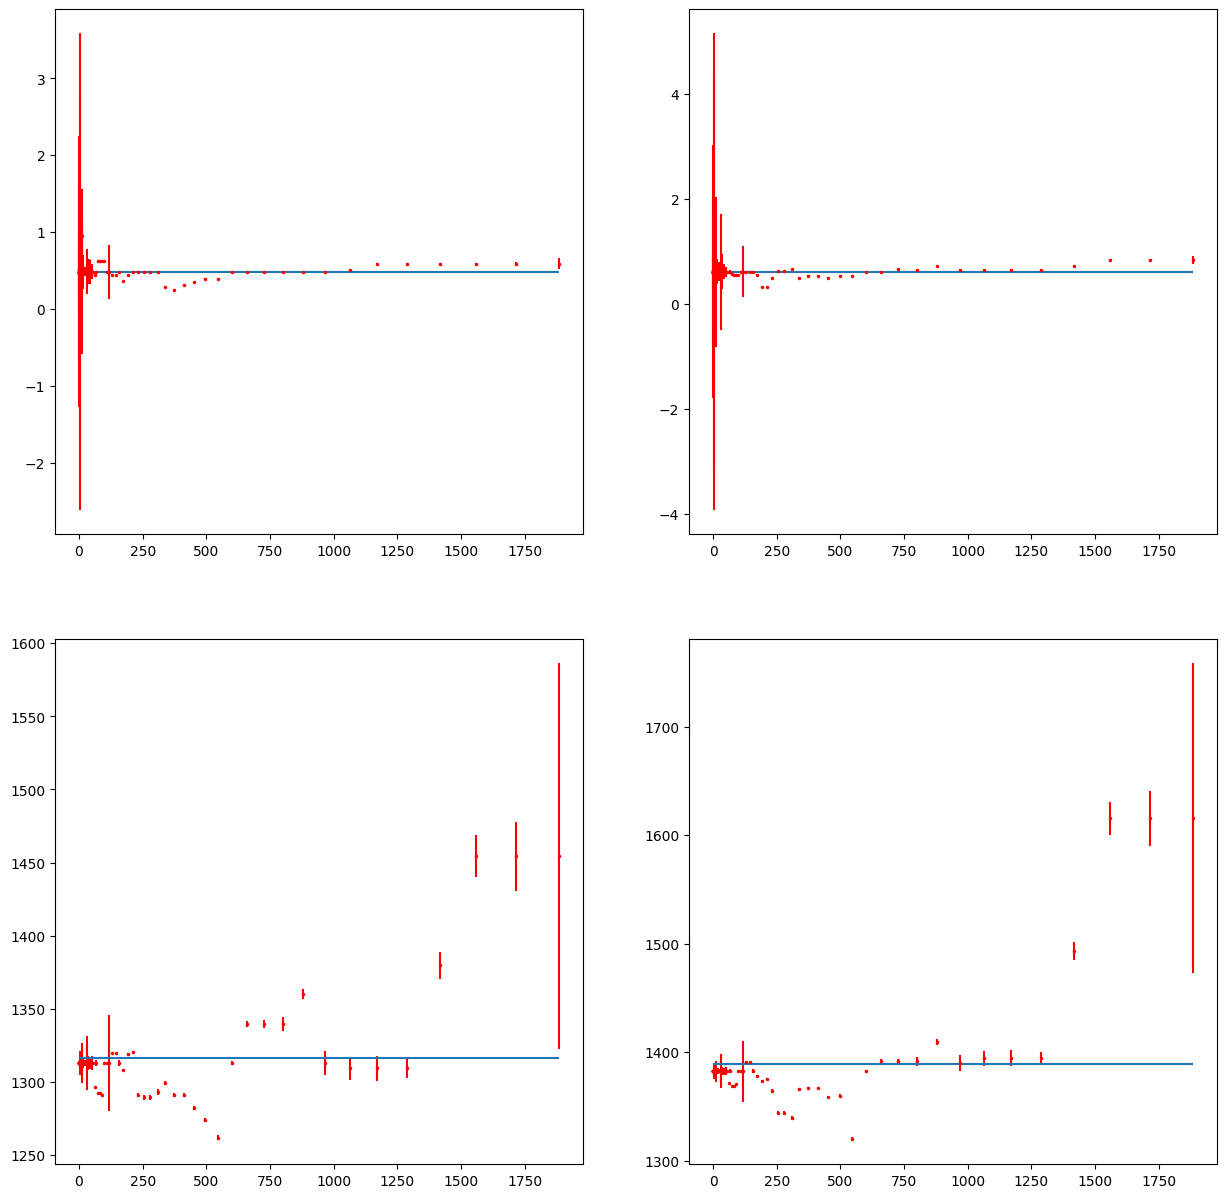

In [24]:
fig,ax = plt.subplots(2,2,figsize=(15,15))

ax[0,0].errorbar(isolist.sma[1:],isolist.eps[1:],yerr=isolist.ellip_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[0,1].errorbar(isolist.sma[1:],isolist.pa[1:],yerr=isolist.pa_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[1,0].errorbar(isolist.sma[1:],isolist.x0[1:],yerr=isolist.x0_err[1:],linestyle='None',marker='.',markersize=3,color='r')
ax[1,1].errorbar(isolist.sma[1:],isolist.y0[1:],yerr=isolist.y0_err[1:],linestyle='None',marker='.',markersize=3,color='r')

ax[0,0].hlines(eps_mean,isolist.sma[0],isolist.sma[-1])
ax[0,1].hlines(pa_mean,isolist.sma[0],isolist.sma[-1])
ax[1,0].hlines(x0_mean,isolist.sma[0],isolist.sma[-1])
ax[1,1].hlines(y0_mean,isolist.sma[0],isolist.sma[-1])

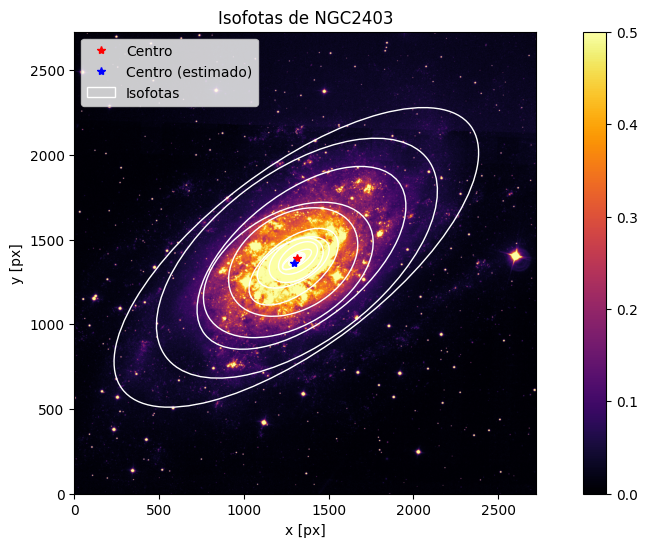

In [25]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(image_g,origin='lower',cmap='inferno')

ax.plot(x0_mean,y0_mean,'r*',label='Centro')
ax.plot(center[0],center[1],'b*',label = 'Centro (estimado)')
#aper.plot(color='white')
isoaper[0].plot(color='white',label='Isofotas')
for i in range(1,len(isoaper)-4,3):
    isoaper[i].plot(color='white')
fig.colorbar(im)
ax.set(title='Isofotas de NGC2403',xlabel='x [px]',ylabel='y [px]')
ax.legend()
plt.savefig('fig4.png')
plt.show()

In [164]:
inc = np.arccos(1-eps_mean)*180/np.pi
Delta_inc = 180/np.pi*(1-eps_mean**2)**-0.5*np.std(isolist.eps)
print(f'{inc}+-{Delta_inc}')

58.91151933045546+-6.184812735039634


In [165]:
int_guess = isolist.get_closest(700).sma

I_bulge = isolist.intens[(isolist.intens<0.49) & (isolist.sma<int_guess)]
a_bulge = isolist.sma[(isolist.intens<0.49) & (isolist.sma<int_guess)]
I_disk = isolist.intens[isolist.sma>=int_guess]
a_disk = isolist.sma[isolist.sma>=int_guess]

In [166]:
devaucouleurs = lambda R,I0,b,Re: I0*np.exp(-b*(R/Re)**0.25)
recta = lambda x,m,b: m*x+b
expprof = lambda R,I0,h: I0*np.exp(-R/h)

In [167]:
pars_bulge, cov_bulge = curve_fit(recta,a_bulge,I_bulge)
pars_disk, cov_disk = curve_fit(recta,a_disk,I_disk)

In [168]:
Dm_bulge, Db_bulge = cov_bulge[0,0]**0.5, cov_bulge[1,1]**0.5
Dm_disk, Db_disk = cov_disk[0,0]**0.5, cov_disk[1,1]**0.5

In [169]:
inters = newton(lambda x: recta(x,*pars_bulge)-recta(x,*pars_disk),700)

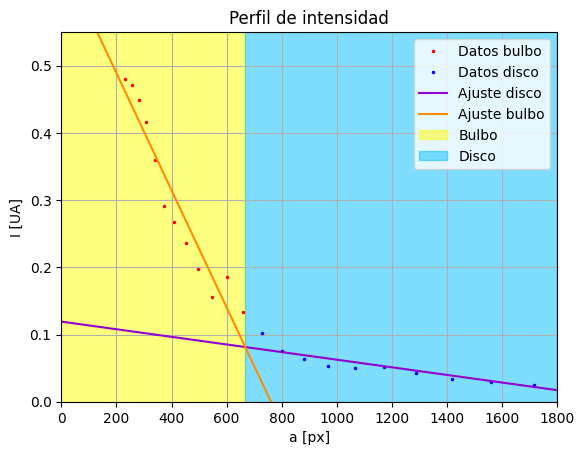

In [170]:
smas = np.linspace(isolist.sma.min(),isolist.sma.max())

plt.plot(a_bulge,I_bulge,'r.',markersize=3,label='Datos bulbo')
plt.plot(a_disk,I_disk,'b.',markersize=3,label='Datos disco')
plt.plot(smas,recta(smas,*pars_disk),color='darkviolet',label='Ajuste disco')
plt.plot(smas,recta(smas,*pars_bulge),color='darkorange',label='Ajuste bulbo')
plt.axvspan(0,inters,0,1,color='yellow',alpha=0.5,label='Bulbo')
plt.axvspan(inters,1800,0,1,color='deepskyblue',alpha=0.5,label='Disco')
plt.xlabel('a [px]')
plt.ylabel('I [UA]')
plt.title('Perfil de intensidad')
plt.grid()
plt.legend()
plt.ylim(0,0.55)
plt.xlim(0,1800)
plt.savefig('fig5.png')


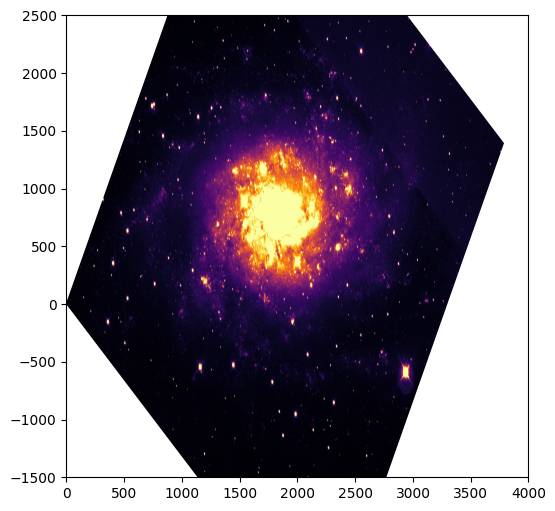

In [33]:
fig, ax = plt.subplots(figsize=(12,6))
#im = ax.imshow(image_g,origin='lower',cmap='inferno')
#aper.plot(color='white')
# for i in range(0,len(isoaper)-4,4):
#     isoaper[i].plot(color='white')


tr = transforms.Affine2D().rotate_deg(-pa_mean*180/np.pi).scale(1,1/(1-eps_mean))

ax.imshow(image_g,origin='lower',cmap='inferno', transform=tr + ax.transData)
ax.set(xlim=(0,4000),ylim=(-1500,2500))
ax.set_box_aspect(1)
plt.show()

In [34]:
corrected_image = rotate(image_g,pa_mean*180/np.pi,reshape=False)
corrected_image = zoom(corrected_image,(1/(1-eps_mean),1))

brazo2 = np.array([[1375,2891],[1250,2907],[1121,2842],[1051,2723],[1062,2556],[1126,2410],[1234,2362],[1407,2335],[1585,2362]])

brazo1 = np.array([[1366,2559],[1434,2547],[1495,2565],[1584,2624],[1636,2759],[1630,2866],[1599,2964],[1550,3059],[1474,3136],[1348,3176],[1225,3166],[1127,3124]])

In [35]:
center_mean = np.array([x0_mean,y0_mean])
center_img = np.array([image_g.shape[0]/2,image_g.shape[1]/2])

corrected_center = center_mean - center_img
rot_mat = np.array([[np.cos(pa_mean),np.sin(pa_mean)],[-np.sin(pa_mean),np.cos(pa_mean)]])

corrected_center = rot_mat@corrected_center
corrected_center += center_img
corrected_center[1] *= 1/(1-eps_mean)

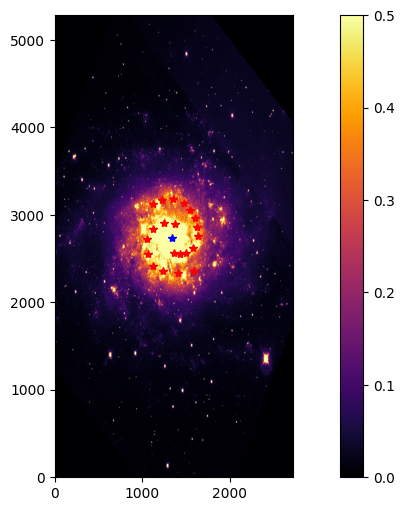

In [36]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,origin='lower',vmin=0,vmax=0.5,cmap='inferno')
ax.plot(brazo1[:,0],brazo1[:,1],'r*')
ax.plot(brazo2[:,0],brazo2[:,1],'r*')
ax.plot(corrected_center[0],corrected_center[1],'b*')
fig.colorbar(im)
plt.show()

In [37]:
z_brazo1 = (brazo1[:,0]-corrected_center[0])+1j*(brazo1[:,1]-corrected_center[1])
z_brazo2 = (brazo2[:,0]-corrected_center[0])+1j*(brazo2[:,1]-corrected_center[1])

polar = np.vectorize(polar)

r_brazo1, th_brazo1 = polar(z_brazo1)
r_brazo2, th_brazo2 = polar(z_brazo2)

df_brazo1 = pd.DataFrame()
df_brazo1['r'] = r_brazo1
df_brazo1['th'] = th_brazo1

df_brazo2 = pd.DataFrame()
df_brazo2['r'] = r_brazo2
df_brazo2['th'] = th_brazo2%(2*np.pi)

df_brazo1 = df_brazo1.sort_values(['th'])
df_brazo2 = df_brazo2.sort_values(['th'])

In [38]:
logspiral = lambda th,a,b: a*b**th

In [39]:
pars_brazo1,cov_brazo1 = curve_fit(logspiral,df_brazo1['th'],df_brazo1['r'])
pars_brazo2,cov_brazo2 = curve_fit(logspiral,df_brazo2['th'],df_brazo2['r'])

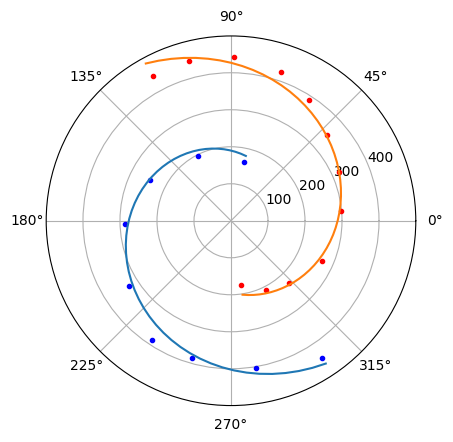

In [40]:
ths1 = np.linspace(df_brazo1['th'].values.min(),df_brazo1['th'].values.max())
ths2 = np.linspace(df_brazo2['th'].values.min(),df_brazo2['th'].values.max())

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(df_brazo1['th'],df_brazo1['r'],'r.')
ax.plot(df_brazo2['th'],df_brazo2['r'],'b.')
ax.plot(ths2,logspiral(ths2,*pars_brazo2))
ax.plot(ths1,logspiral(ths1,*pars_brazo1))

In [41]:
rect = np.vectorize(rect)
xs_brazo1 = rect(r_brazo1,th_brazo1).real+corrected_center[0]
ys_brazo1 = rect(r_brazo1,th_brazo1).imag+corrected_center[1]
xs_brazo2 = rect(r_brazo2,th_brazo2).real+corrected_center[0]
ys_brazo2 = rect(r_brazo2,th_brazo2).imag+corrected_center[1]

xs_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).real+corrected_center[0]
ys_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).imag+corrected_center[1]
xs_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).real+corrected_center[0]
ys_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).imag+corrected_center[1]

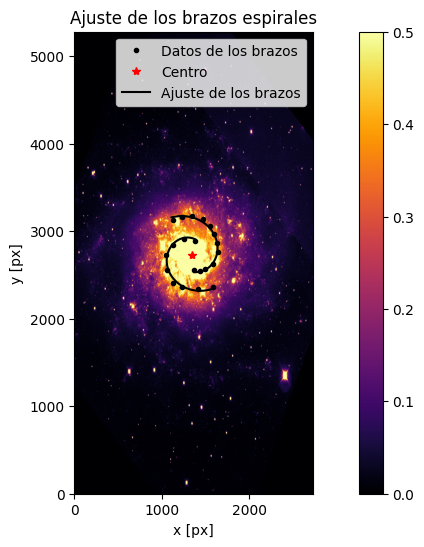

In [42]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,vmin=0,vmax=0.5,cmap='inferno',origin='lower')
ax.plot(xs_brazo1,ys_brazo1,'k.',label='Datos de los brazos')
ax.plot(xs_brazo2,ys_brazo2,'k.')
ax.plot(corrected_center[0],corrected_center[1],'r*',label='Centro')
ax.plot(xs_brazo1_fit,ys_brazo1_fit,'k',label='Ajuste de los brazos')
ax.plot(xs_brazo2_fit,ys_brazo2_fit,'k')
ax.set(title='Ajuste de los brazos espirales',xlabel='x [px]',ylabel='y [px]')
ax.legend()
fig.colorbar(im)
plt.savefig('fig6.png')
plt.show()

In [43]:
pitch_angle_1 = np.arctan(np.log(pars_brazo1[1]))*180/np.pi
pitch_angle_2 = np.arctan(np.log(pars_brazo2[1]))*180/np.pi

DPA1 = 1/(pars_brazo1[1]*(1+np.log(pars_brazo1[1])**2))*cov_brazo1[1,1]**0.5
DPA2 = 1/(pars_brazo2[1]*(1+np.log(pars_brazo2[1])**2))*cov_brazo2[1,1]**0.5

print(f'{pitch_angle_1}+-{DPA1}, {pitch_angle_2}+-{DPA2}')

14.037984934707213+-0.016434857387083265, 13.47174583350627+-0.018377489067533205


In [44]:
R = []
V = []
with open(r"NGC2403_Rot_Curve.dat") as datFile:
    R = [data.split()[0] for data in datFile]
with open(r"NGC2403_Rot_Curve.dat") as datFile:
    V = [data.split()[1] for data in datFile]

R.remove(R[0])
R = [float(item) for item in R]

V.remove(V[0])
V = [float(item) for item in V]

df = pd.DataFrame()
df['R(kpc)'] = R
df['V(km/s)'] = V
df

,R(kpc),V(km/s)
0,0.00,47.90000
1,0.05,53.95123
2,0.10,60.44677
3,0.15,66.02752
4,0.20,69.54928
...,...,...
390,19.50,135.39999
391,19.55,135.39999
392,19.60,135.39999
393,19.65,135.39999


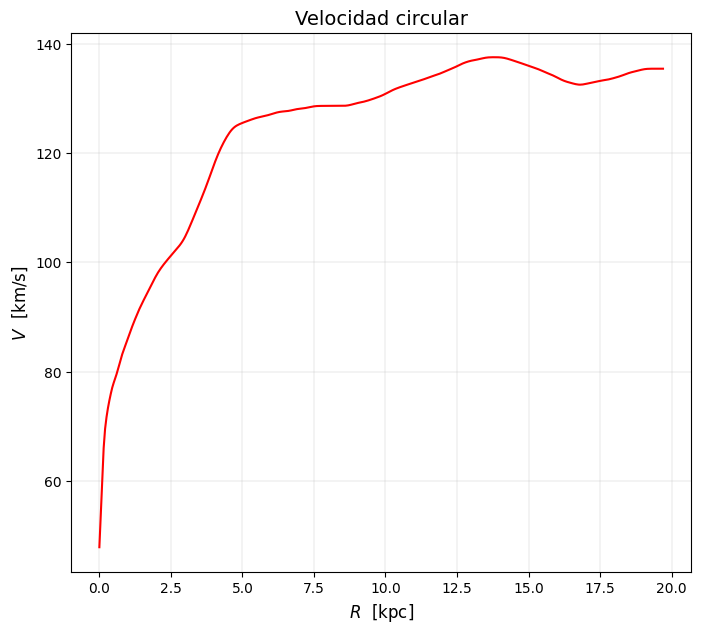

In [45]:
plt.figure(figsize=(8,7))
plt.plot(R,V, '-', color = 'r')
plt.xlabel('$R~ $ [kpc]',fontsize = 12)
plt.ylabel('$V~ $ [km/s]' ,fontsize = 12)
plt.title("Velocidad circular",fontsize = 14)
plt.grid(linestyle='-', linewidth=0.2)
plt.savefig('fig7.png')

In [46]:
Vmax = np.max(V)
Vmax

137.49854

In [47]:
MBc = -11*np.log10(Vmax)+3.31
mBc = 8.83

dc = 10**((mBc-MBc+5)/5)
dc

6430663.590668216

In [48]:
MBb = -10.2*np.log10(Vmax)+2.71
mBb = 8.83

db = 10**((mBb-MBb+5)/5)
db 

3855920.7283871197

In [49]:
pars_disk_e, cov_disk_e = curve_fit(expprof,a_disk,I_disk,p0=(0.5,700))

In [50]:
header = NGC2403_g[0].header

plate_scale_deg_per_pix = np.abs(header.get('CDELT2', header.get('CDELT1', 0))) # Grados/pix
if plate_scale_deg_per_pix == 0:
    # Si CDELT no existe, buscar la matriz CD
    cd1_1 = header.get('CD1_1', 0)
    cd1_2 = header.get('CD1_2', 0)
    cd2_1 = header.get('CD2_1', 0)
    cd2_2 = header.get('CD2_2', 0)
    # La escala de placa es la raíz cuadrada del determinante de la matriz CD (si es diagonal o no rotada significativamente)
    # o simplemente los elementos diagonales si está alineada con los ejes.
    # Para una estimación simple, si CD1_2 y CD2_1 son pequeños, podemos usar CD1_1 y CD2_2
    if np.isclose(cd1_2, 0) and np.isclose(cd2_1, 0):
         plate_scale_deg_per_pix = np.sqrt(np.abs(cd1_1 * cd2_2))
    else:
         # Si hay rotación, la escala no es tan simple, pero CDELT1/2 son más comunes
         # Usaremos una aproximación o indicaremos que no se encontró una escala clara
         print("Advertencia: Matriz CD encontrada, pero no simple diagonal. Usando CDELT si existe.")
         plate_scale_deg_per_pix = np.abs(header.get('CDELT2', header.get('CDELT1', 0)))


if plate_scale_deg_per_pix == 0:
     print("No se pudo determinar la escala de placa del encabezado FITS (buscando CDELT1, CDELT2, CD1_1, CD2_2).")
     print("No se puede convertir la longitud de escala a unidades físicas.")
else:
    # Convertir a arcsec/pix
    plate_scale_arcsec_per_pix = plate_scale_deg_per_pix * 3600 # arcsec/deg * deg/pix

In [51]:
h_pix = pars_disk_e[1]
h_pix

717.6421916547655

In [52]:
h_arcsec = h_pix * plate_scale_arcsec_per_pix # arcsec

# Convertir h_arcsec a h_kpc
h_kpc = dc*1e-3 * (h_arcsec / 206265) # 1 radian = 206265 arcsec
h_kpc

8.85999337380015

In [215]:
h_arcsec = h_pix * plate_scale_arcsec_per_pix # arcsec

# Convertir h_arcsec a h_kpc
h_kpc = 3.4*1e-3 * (h_arcsec / 206265) # 1 radian = 206265 arcsec
h_kpc

4.684427516101848e-06

## 2

In [54]:
# elípticas
M32 = fits.open('NGC_0221_I_B_l2007.fits')
M60 = fits.open('PGC_040653_I_g_bbl2011.fits')

# espirales
M51 = fits.open('NGC_5194_I_B_kab2003.fits')
NGC3938 = fits.open('NGC_3938_SDSS_g_bms2014.fits')

PACKEND                                                                          [astropy.io.fits.card]


#### Elípticas

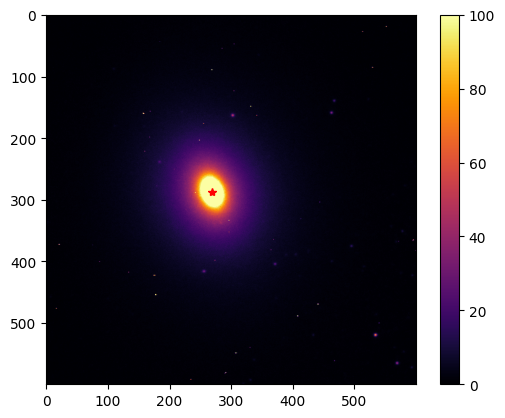

In [55]:
M32_img = M32[0].data
M32_img = M32_img[200:800,200:800]

center_M32 = cen.centroid_2dg(M32_img)

plt.imshow(M32_img,cmap='inferno',vmin=0,vmax=100)
plt.plot(center_M32[0],center_M32[1],'r*')
plt.colorbar()

/tmp/ipykernel_12422/1423009750.py:1: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(M32_img.reshape(M32_img.size))


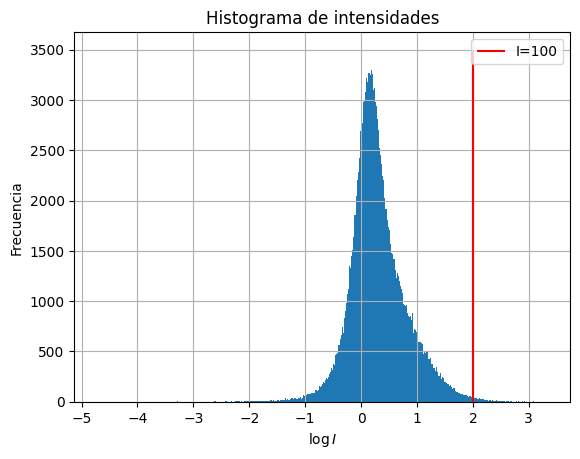

In [56]:
data_hist = np.log10(M32_img.reshape(M32_img.size))
n_bins = 1000

fig, ax = plt.subplots()
hist = ax.hist(data_hist,n_bins)
ax.vlines(np.log10(100),0,3500,'r',label='I=100')
ax.set(title='Histograma de intensidades',xlabel=r'$\log I$',ylabel='Frecuencia')
ax.grid()
ax.legend()
#plt.savefig('hist.png')
plt.show()

In [57]:
cond0 = M32_img>=100
cond = cond0[200:300,250:350]

dist = np.zeros_like(cond0)
dist[200:300,250:350] = cond

In [58]:
xx = np.arange(cond0.shape[0])
yy = np.arange(cond0.shape[0])

XX,YY = np.meshgrid(xx,yy)

xs_dist = XX[dist]
ys_dist = YY[dist]

In [59]:
cov = np.cov(xs_dist,ys_dist)
eigvals, eigvecs = np.linalg.eigh(cov)  # eigh porque la covarianza es simétrica

# Ordenar de mayor a menor
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

angle = np.arctan(eigvecs[1,0]/eigvecs[0,0])

sma = 3*eigvals[0]**0.5
eps = 1 - eigvals[1]/eigvals[0]

In [60]:
geometry = isoph.EllipseGeometry(x0=center_M32[0], y0=center_M32[1], sma=sma, eps=eps,
                           pa=angle)

In [61]:
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          geometry.pa)

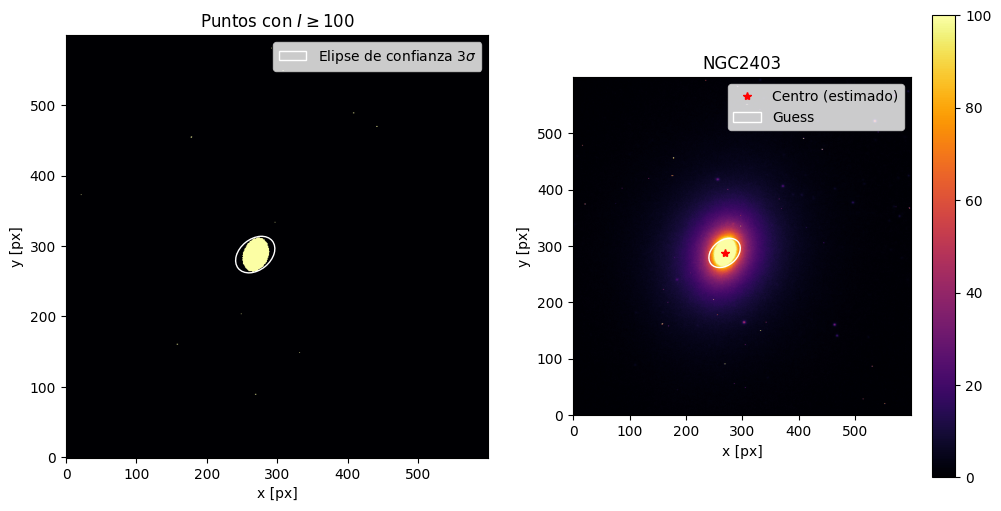

In [62]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(cond0,origin='lower',cmap='inferno')
#ax.plot(center[0],center[1],'r*')
aper.plot(ax[0],color='white',label=r'Elipse de confianza $3\sigma$')
im = ax[1].imshow(M32_img,origin='lower',vmin=0,vmax=100,cmap='inferno')
ax[1].plot(center_M32[0],center_M32[1],'r*',label='Centro (estimado)')
aper.plot(color='white',label='Guess')
ax[0].set(title=r'Puntos con $I\geq 100$',xlabel='x [px]',ylabel='y [px]')
ax[1].set(title=r'NGC2403',xlabel='x [px]',ylabel='y [px]')
ax[0].legend()
ax[1].legend()
fig.colorbar(im)
#plt.savefig('fig3.png')
plt.show()

In [63]:
ellipse = isoph.Ellipse(M32_img,geometry)
isolist = ellipse.fit_image()

In [64]:
isogeom = []
isoaper = []
for iso in isolist[1:]:
    isogeom.append(isoph.EllipseGeometry(x0=iso.x0, y0=iso.y0, sma=iso.sma, eps=iso.eps,
                           pa=iso.pa))
    
for geom in isogeom:
    isoaper.append(EllipticalAperture((geom.x0, geom.y0), geom.sma, geom.sma * (1 - geom.eps), geom.pa))

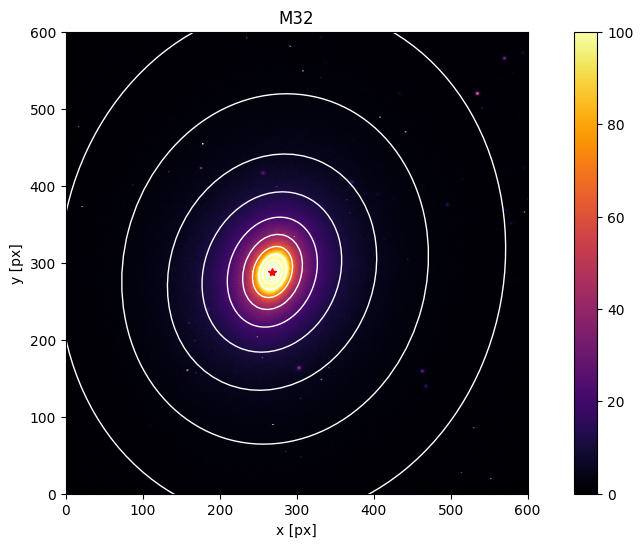

In [65]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(M32_img,origin='lower',cmap='inferno',vmin=0,vmax=100)
ax.plot(center_M32[0],center_M32[1],'r*')
#aper.plot(color='white')
for i in range(0,len(isoaper),4):
    isoaper[i].plot(color='white')
fig.colorbar(im)
plt.title('M32')
plt.xlabel('x [px]')
plt.ylabel('y [px]')
plt.xlim(0,600)
plt.ylim(0,600)
plt.savefig('fig8.png')
plt.show()

In [66]:
np.mean(isolist.eps)

0.2024044789912344

E2
_________________________

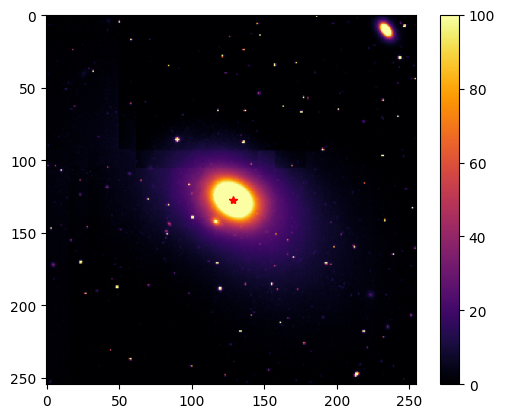

In [175]:
M60_img = M60[0].data
center_M60 = cen.centroid_2dg(M60_img)

plt.imshow(M60_img,cmap='inferno',vmin=0,vmax=100)
plt.plot(center_M60[0],center_M60[1],'r*')
plt.colorbar()

/tmp/ipykernel_12422/2354084402.py:1: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(M60_img.reshape(M60_img.size))
/tmp/ipykernel_12422/2354084402.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


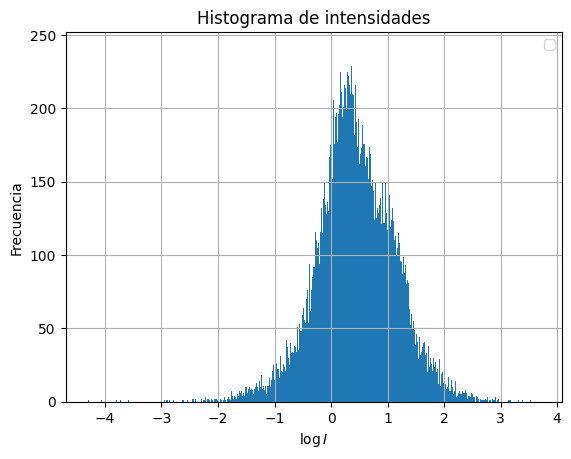

In [176]:
data_hist = np.log10(M60_img.reshape(M60_img.size))
n_bins = 1000

fig, ax = plt.subplots()
hist = ax.hist(data_hist,n_bins)
#ax.vlines(np.log10(100),0,3500,'r',label='I=100')
ax.set(title='Histograma de intensidades',xlabel=r'$\log I$',ylabel='Frecuencia')
ax.grid()
ax.legend()
#plt.savefig('hist.png')
plt.show()

In [177]:
cond0 = M60_img>=100
cond = cond0[100:150,100:150]

dist = np.zeros_like(cond0)
dist[100:150,100:150] = cond

In [178]:
xx = np.arange(cond0.shape[0])
yy = np.arange(cond0.shape[0])

XX,YY = np.meshgrid(xx,yy)

xs_dist = XX[dist]
ys_dist = YY[dist]

In [179]:
cov = np.cov(xs_dist,ys_dist)
eigvals, eigvecs = np.linalg.eigh(cov)  # eigh porque la covarianza es simétrica

# Ordenar de mayor a menor
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

angle = np.arctan(eigvecs[1,0]/eigvecs[0,0])

sma = 3*eigvals[0]**0.5
eps = 1 - eigvals[1]/eigvals[0]

In [180]:
geometry = isoph.EllipseGeometry(x0=center_M60[0], y0=center_M60[1], sma=sma, eps=eps,
                           pa=angle)

In [181]:
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          geometry.pa)

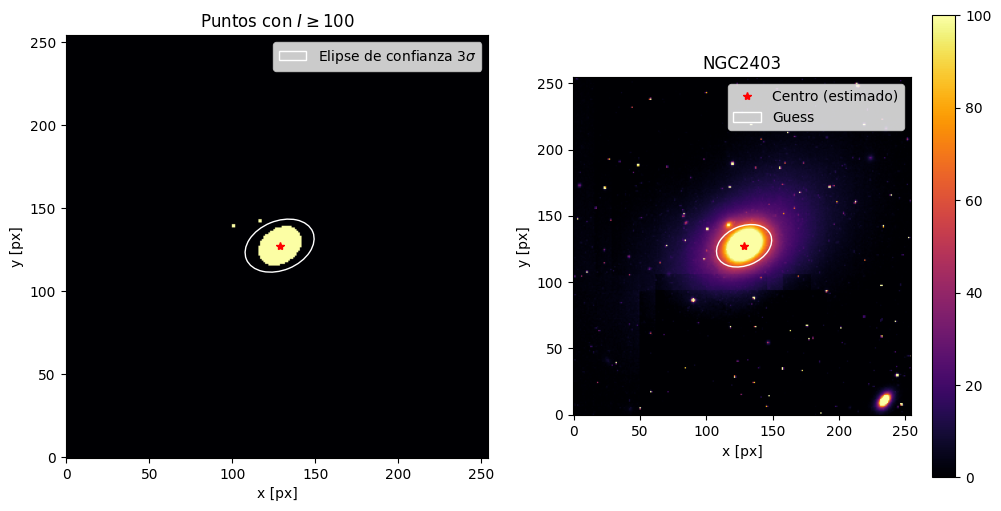

In [182]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(dist,origin='lower',cmap='inferno')
ax[0].plot(center_M60[0],center_M60[1],'r*')
aper.plot(ax[0],color='white',label=r'Elipse de confianza $3\sigma$')
im = ax[1].imshow(M60_img,origin='lower',vmin=0,vmax=100,cmap='inferno')
ax[1].plot(center_M60[0],center_M60[1],'r*',label='Centro (estimado)')
aper.plot(color='white',label='Guess')
ax[0].set(title=r'Puntos con $I\geq 100$',xlabel='x [px]',ylabel='y [px]')
ax[1].set(title=r'NGC2403',xlabel='x [px]',ylabel='y [px]')
ax[0].legend()
ax[1].legend()
fig.colorbar(im)
#plt.savefig('fig3.png')
plt.show()

In [183]:
ellipse = isoph.Ellipse(M60_img,geometry)
isolist = ellipse.fit_image()

In [184]:
isogeom = []
isoaper = []
for iso in isolist[1:]:
    isogeom.append(isoph.EllipseGeometry(x0=iso.x0, y0=iso.y0, sma=iso.sma, eps=iso.eps,
                           pa=iso.pa))
    
for geom in isogeom:
    isoaper.append(EllipticalAperture((geom.x0, geom.y0), geom.sma, geom.sma * (1 - geom.eps), geom.pa))

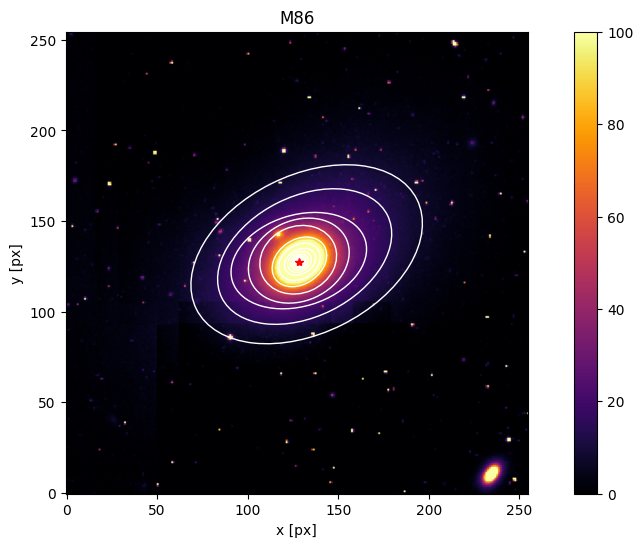

In [185]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(M60_img,origin='lower',cmap='inferno',vmin=0,vmax=100)
ax.plot(center_M60[0],center_M60[1],'r*')
#aper.plot(color='white')
for i in range(0,len(isoaper),3):
    isoaper[i].plot(color='white')
fig.colorbar(im)
plt.title('M86')
plt.xlabel('x [px]')
plt.ylabel('y [px]')
plt.savefig('fig9.png')
plt.show()

In [78]:
np.mean(isolist.eps)

0.21000355021153777

E2
______________

#### Espirales

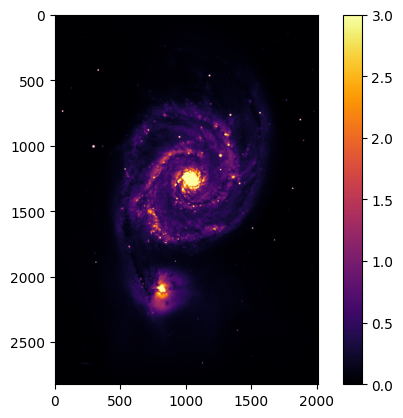

In [79]:
M51_img = M51[0].data

plt.imshow(M51_img,cmap='inferno',vmin=0,vmax=3)
#plt.plot(center_M51[0],center_M51[1],'r*')
plt.colorbar()

/tmp/ipykernel_12422/2787895469.py:3: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(data_hist)
/tmp/ipykernel_12422/2787895469.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


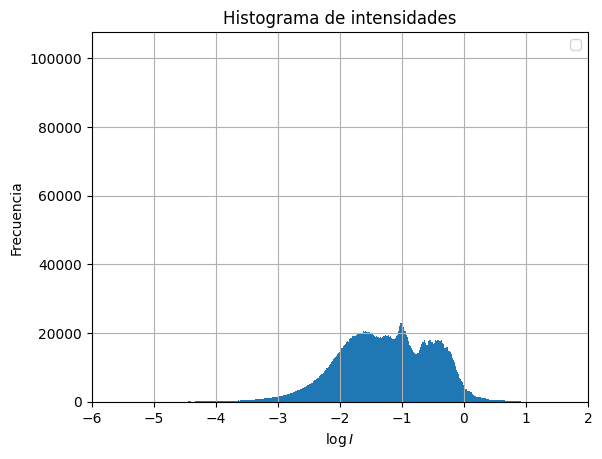

In [80]:
data_hist = M51_img.reshape(M51_img.size)
data_hist[data_hist==0] = 1e-7
data_hist = np.log10(data_hist)
n_bins = 1000

fig, ax = plt.subplots()
hist = ax.hist(data_hist,n_bins)
#ax.vlines(np.log10(100),0,3500,'r',label='I=100')
ax.set(title='Histograma de intensidades',xlabel=r'$\log I$',ylabel='Frecuencia')
ax.grid()
ax.legend()
ax.set_xlim(-6,2)
#plt.savefig('hist.png')
plt.show()

In [81]:
cond0 = M51_img>=3
cond = cond0[1000:1500,750:1250]

dist = np.zeros_like(cond0)
dist[1000:1500,750:1250] = cond

In [82]:
xx = np.arange(cond0.shape[0])
yy = np.arange(cond0.shape[1])

XX,YY = np.meshgrid(xx,yy)

XX.shape,YY.shape

xs_dist = XX[dist.T]
ys_dist = YY[dist.T]

In [83]:
cov = np.cov(xs_dist,ys_dist)
eigvals, eigvecs = np.linalg.eigh(cov)  # eigh porque la covarianza es simétrica

# Ordenar de mayor a menor
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

angle = np.arctan(eigvecs[1,0]/eigvecs[0,0])

sma = 3*eigvals[0]**0.5
eps = 1 - eigvals[1]/eigvals[0]

In [84]:
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          geometry.pa)

In [85]:
pa_mean = 12*np.pi/180
eps_mean = 1 - np.cos(20.3*np.pi/180)

corrected_image = rotate(M51_img,pa_mean*180/np.pi,reshape=False)
corrected_image = zoom(corrected_image,(1/(1-eps_mean),1))

brazo1 = np.array([[913,1368],[923,1437],[957,1494],[1011,1532],[1093,1532],[1185,1482],[1226,1425],[1267,1352],[1283,1286],[1295,1226]])

brazo2 = np.array([[1080,1314],[1068,1242],[1030,1191],[967,1172],[878,1169],[793,1210],[765,1276],[746,1346]])

In [86]:
# center_mean = np.array([x0_mean,y0_mean])
# center_img = np.array([image_g.shape[0]/2,image_g.shape[1]/2])

# corrected_center = center_mean - center_img
# rot_mat = np.array([[np.cos(pa_mean),np.sin(pa_mean)],[-np.sin(pa_mean),np.cos(pa_mean)]])

# corrected_center = rot_mat@corrected_center
# corrected_center += center_img
# corrected_center[1] *= 1/(1-eps_mean)

corrected_center = [1002,1352]

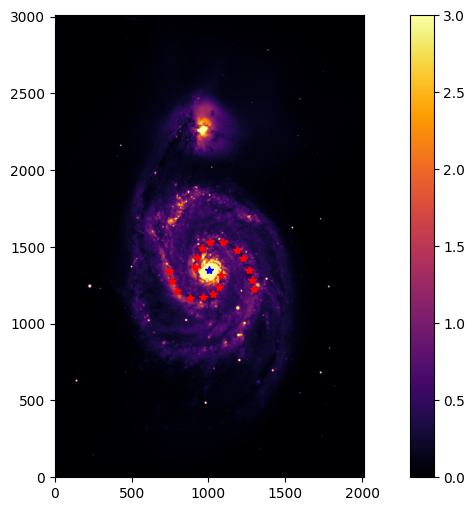

In [87]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,origin='lower',vmin=0,vmax=3,cmap='inferno')
ax.plot(brazo1[:,0],brazo1[:,1],'r*')
ax.plot(brazo2[:,0],brazo2[:,1],'r*')
ax.plot(corrected_center[0],corrected_center[1],'b*')
fig.colorbar(im)
plt.show()

In [88]:
z_brazo1 = (brazo1[:,0]-corrected_center[0])+1j*(brazo1[:,1]-corrected_center[1])
z_brazo2 = (brazo2[:,0]-corrected_center[0])+1j*(brazo2[:,1]-corrected_center[1])

polar = np.vectorize(polar)

r_brazo1, th_brazo1 = polar(z_brazo1)
r_brazo2, th_brazo2 = polar(z_brazo2)

df_brazo1 = pd.DataFrame()
df_brazo1['r'] = r_brazo1
df_brazo1['th'] = th_brazo1

df_brazo2 = pd.DataFrame()
df_brazo2['r'] = r_brazo2
df_brazo2['th'] = th_brazo2%(2*np.pi)

df_brazo1 = df_brazo1.sort_values(['th'])
df_brazo2 = df_brazo2.sort_values(['th'])

In [89]:
pars_brazo1,cov_brazo1 = curve_fit(logspiral,df_brazo1['th'],df_brazo1['r'])
pars_brazo2,cov_brazo2 = curve_fit(logspiral,df_brazo2['th'],df_brazo2['r'])

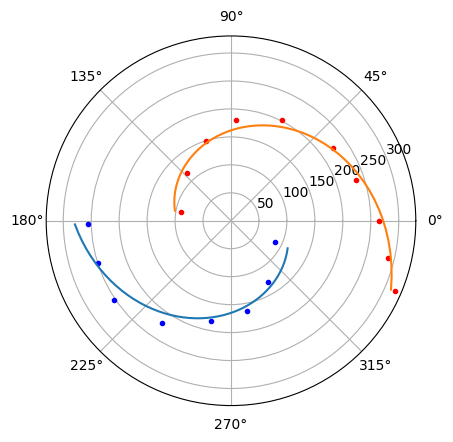

In [90]:
ths1 = np.linspace(df_brazo1['th'].values.min(),df_brazo1['th'].values.max())
ths2 = np.linspace(df_brazo2['th'].values.min(),df_brazo2['th'].values.max())

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(df_brazo1['th'],df_brazo1['r'],'r.')
ax.plot(df_brazo2['th'],df_brazo2['r'],'b.')
ax.plot(ths2,logspiral(ths2,*pars_brazo2))
ax.plot(ths1,logspiral(ths1,*pars_brazo1))

In [91]:
rect = np.vectorize(rect)
xs_brazo1 = rect(r_brazo1,th_brazo1).real+corrected_center[0]
ys_brazo1 = rect(r_brazo1,th_brazo1).imag+corrected_center[1]
xs_brazo2 = rect(r_brazo2,th_brazo2).real+corrected_center[0]
ys_brazo2 = rect(r_brazo2,th_brazo2).imag+corrected_center[1]

xs_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).real+corrected_center[0]
ys_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).imag+corrected_center[1]
xs_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).real+corrected_center[0]
ys_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).imag+corrected_center[1]

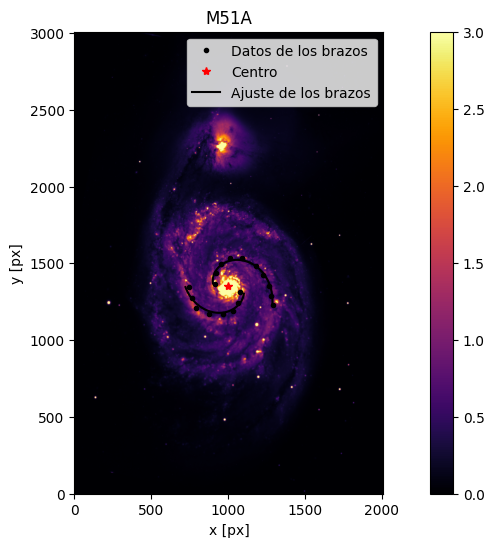

In [92]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(corrected_image,vmin=0,vmax=3,cmap='inferno',origin='lower')
ax.plot(xs_brazo1,ys_brazo1,'k.',label='Datos de los brazos')
ax.plot(xs_brazo2,ys_brazo2,'k.')
ax.plot(corrected_center[0],corrected_center[1],'r*',label='Centro')
ax.plot(xs_brazo1_fit,ys_brazo1_fit,'k',label='Ajuste de los brazos')
ax.plot(xs_brazo2_fit,ys_brazo2_fit,'k')
ax.set(title='M51A',xlabel='x [px]',ylabel='y [px]')
ax.legend()
fig.colorbar(im)
plt.savefig('fig10.png')
plt.show()

In [93]:
pitch_angle_1 = np.arctan(np.log(pars_brazo1[1]))*180/np.pi
pitch_angle_2 = np.arctan(np.log(pars_brazo2[1]))*180/np.pi

DPA1 = 1/(pars_brazo1[1]*(1+np.log(pars_brazo1[1])**2))*cov_brazo1[1,1]**0.5
DPA2 = 1/(pars_brazo2[1]*(1+np.log(pars_brazo2[1])**2))*cov_brazo2[1,1]**0.5

print(f'{pitch_angle_1}+-{DPA1}, {pitch_angle_2}+-{DPA2}')

-18.343221841915327+-0.016394109205833108, -18.813214027008243+-0.04207296765564239


Sc
___________

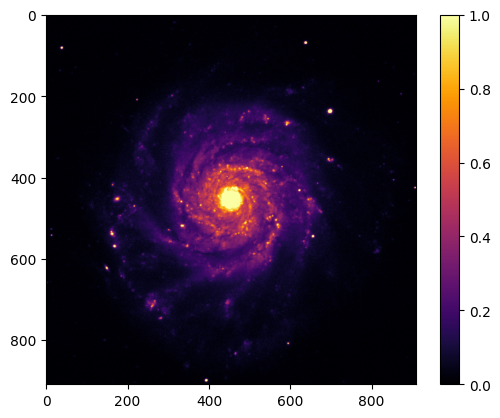

In [94]:
NGC3938_img = NGC3938[0].data

plt.imshow(NGC3938_img,cmap='inferno',vmin=0,vmax=1)
plt.colorbar()

/tmp/ipykernel_12422/182333792.py:1: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(NGC3938_img.reshape(NGC3938_img.size))
/tmp/ipykernel_12422/182333792.py:3: RuntimeWarning: invalid value encountered in log10
  data_hist = np.log10(data_hist)
/tmp/ipykernel_12422/182333792.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


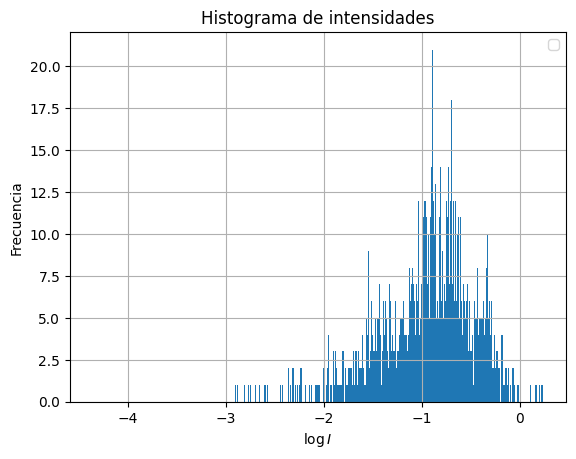

In [95]:
data_hist = np.log10(NGC3938_img.reshape(NGC3938_img.size))
data_hist[data_hist==0] = 1e-7
data_hist = np.log10(data_hist)
n_bins = 1000

fig, ax = plt.subplots()
hist = ax.hist(data_hist,n_bins)
#ax.vlines(np.log10(100),0,3500,'r',label='I=100')
ax.set(title='Histograma de intensidades',xlabel=r'$\log I$',ylabel='Frecuencia')
ax.grid()
ax.legend()
#ax.set_xlim(-6,2)
#plt.savefig('hist.png')
plt.show()

In [96]:
brazo1 = np.array([[471.3,429],[498.1,452.5],[503.8,485.9],[496.5,518.4],[468,539.6],[440.4,539.6],[411.9,529.8]])
brazo2 = np.array([[432.2,479.4],[413.5,455.8],[415.1,426.5],[435.5,398.9],[457.4,385],[492.4,384.2],[520.9,394.8]])
corrected_center = np.array([452,452])

In [97]:
z_brazo1 = (brazo1[:,0]-corrected_center[0])+1j*(brazo1[:,1]-corrected_center[1])
z_brazo2 = (brazo2[:,0]-corrected_center[0])+1j*(brazo2[:,1]-corrected_center[1])

polar = np.vectorize(polar)

r_brazo1, th_brazo1 = polar(z_brazo1)
r_brazo2, th_brazo2 = polar(z_brazo2)

df_brazo1 = pd.DataFrame()
df_brazo1['r'] = r_brazo1
df_brazo1['th'] = th_brazo1

df_brazo2 = pd.DataFrame()
df_brazo2['r'] = r_brazo2
df_brazo2['th'] = th_brazo2%(2*np.pi)

df_brazo1 = df_brazo1.sort_values(['th'])
df_brazo2 = df_brazo2.sort_values(['th'])

In [98]:
pars_brazo1,cov_brazo1 = curve_fit(logspiral,df_brazo1['th'],df_brazo1['r'])
pars_brazo2,cov_brazo2 = curve_fit(logspiral,df_brazo2['th'],df_brazo2['r'])

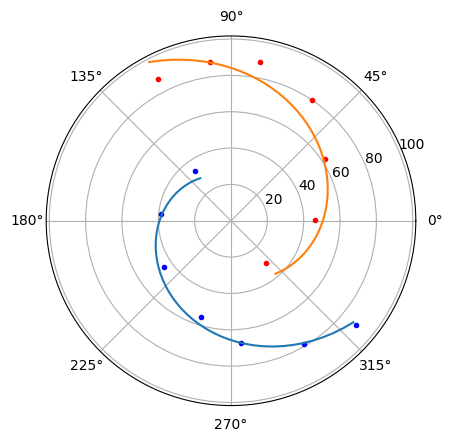

In [99]:
ths1 = np.linspace(df_brazo1['th'].values.min(),df_brazo1['th'].values.max())
ths2 = np.linspace(df_brazo2['th'].values.min(),df_brazo2['th'].values.max())

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(df_brazo1['th'],df_brazo1['r'],'r.')
ax.plot(df_brazo2['th'],df_brazo2['r'],'b.')
ax.plot(ths2,logspiral(ths2,*pars_brazo2))
ax.plot(ths1,logspiral(ths1,*pars_brazo1))

In [100]:
rect = np.vectorize(rect)
xs_brazo1 = rect(r_brazo1,th_brazo1).real+corrected_center[0]
ys_brazo1 = rect(r_brazo1,th_brazo1).imag+corrected_center[1]
xs_brazo2 = rect(r_brazo2,th_brazo2).real+corrected_center[0]
ys_brazo2 = rect(r_brazo2,th_brazo2).imag+corrected_center[1]

xs_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).real+corrected_center[0]
ys_brazo1_fit = rect(logspiral(ths1,*pars_brazo1),ths1).imag+corrected_center[1]
xs_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).real+corrected_center[0]
ys_brazo2_fit = rect(logspiral(ths2,*pars_brazo2),ths2).imag+corrected_center[1]

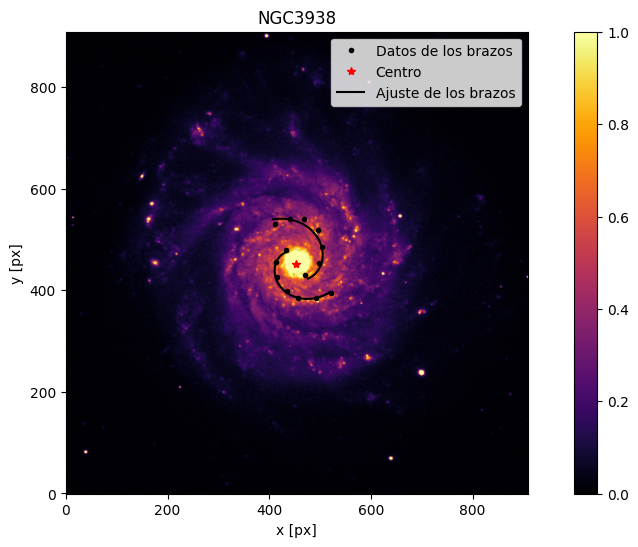

In [101]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(NGC3938_img,vmin=0,vmax=1,cmap='inferno',origin='lower')
ax.plot(xs_brazo1,ys_brazo1,'k.',label='Datos de los brazos')
ax.plot(xs_brazo2,ys_brazo2,'k.')
ax.plot(corrected_center[0],corrected_center[1],'r*',label='Centro')
ax.plot(xs_brazo1_fit,ys_brazo1_fit,'k',label='Ajuste de los brazos')
ax.plot(xs_brazo2_fit,ys_brazo2_fit,'k')
ax.set(title='NGC3938',xlabel='x [px]',ylabel='y [px]')
ax.legend()
fig.colorbar(im)
plt.savefig('fig11.png')
plt.show()

In [102]:
pitch_angle_1 = np.arctan(np.log(pars_brazo1[1]))*180/np.pi
pitch_angle_2 = np.arctan(np.log(pars_brazo2[1]))*180/np.pi

DPA1 = 1/(pars_brazo1[1]*(1+np.log(pars_brazo1[1])**2))*cov_brazo1[1,1]**0.5
DPA2 = 1/(pars_brazo2[1]*(1+np.log(pars_brazo2[1])**2))*cov_brazo2[1,1]**0.5

print(f'{pitch_angle_1}+-{DPA1}, {pitch_angle_2}+-{DPA2}')

17.983593348792688+-0.05721493386790164, 18.08393772973612+-0.021417998011295496


## 3

In [216]:
cumulos = pd.read_csv('GCs_MW_vf.csv')

x_ = []
y_ = []
z_ = []
with open(r"disquito.dat") as datFile:
    x_ = [data.split()[0] for data in datFile]
with open(r"disquito.dat") as datFile:
    y_ = [data.split()[1] for data in datFile]
with open(r"disquito.dat") as datFile:
    z_ = [data.split()[2] for data in datFile]

disco = pd.DataFrame()
disco['x'] = np.array(x_).astype(float)
disco['y'] = np.array(y_).astype(float)
disco['z'] = np.array(z_).astype(float)

new_names = {cumulos.columns[i]:cumulos.columns[i].replace(' ','') for i in range(len(cumulos.columns))}
cumulos = cumulos.rename(columns=new_names)

cumulos[[cumulos == '     ']] = np.nan
cumulos[[cumulos == ' ']] = np.nan

for i in cumulos.columns[3:]:
    cumulos[i] = cumulos[i].astype(float)

cumulos['x'] = cumulos['Rsun']*np.cos(cumulos['GLAT']*np.pi/180)*np.cos(cumulos['GLON']*np.pi/180)-8
cumulos['y'] = cumulos['Rsun']*np.cos(cumulos['GLAT']*np.pi/180)*np.sin(cumulos['GLON']*np.pi/180)
cumulos['z'] = cumulos['Rsun']*np.sin(cumulos['GLAT']*np.pi/180)


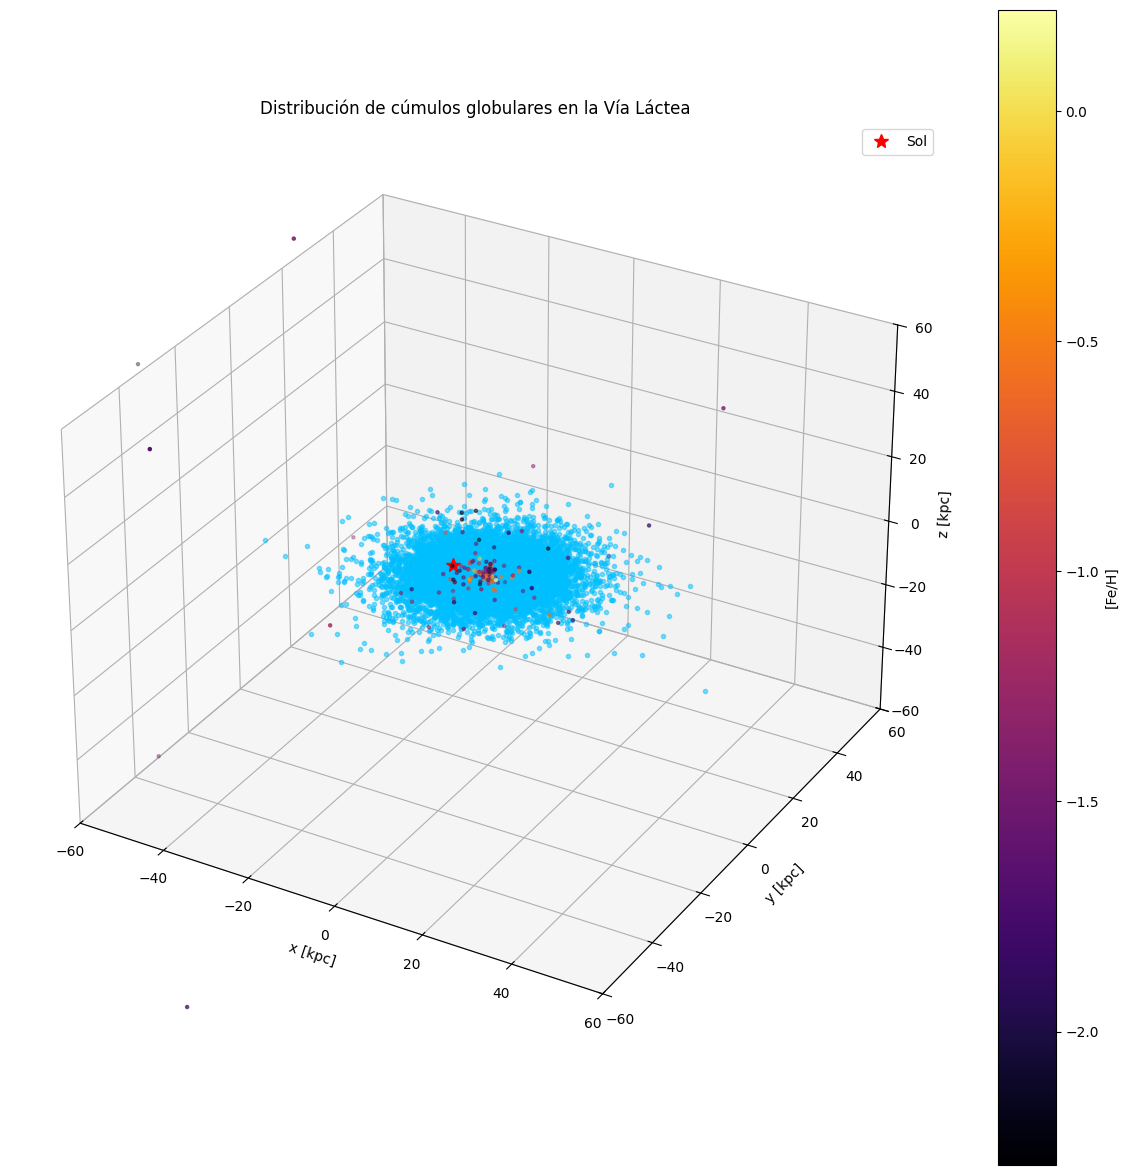

In [225]:

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(projection='3d')   
ax.set(xlim=(-60,60),ylim=(-60,60),zlim=(-60,60))


ax.plot(disco['x'].values,disco['y'].values,disco['z'].values,color='deepskyblue',alpha=0.5,marker='.',linestyle='none')
sc = ax.scatter(cumulos['x'].values,cumulos['y'].values,cumulos['z'].values,marker='.',c=cumulos['Fe/H'].values,cmap='inferno')
ax.plot(-8,0,0,color='r',marker='*',linestyle='none',label='Sol',markersize=10)
ax.set(title='Distribución de cúmulos globulares en la Vía Láctea',xlabel='x [kpc]',ylabel='y [kpc]',zlabel='z [kpc]')
fig.colorbar(sc, ax=ax, label='[Fe/H]')
ax.legend()
plt.savefig('fig12.png')
plt.show()

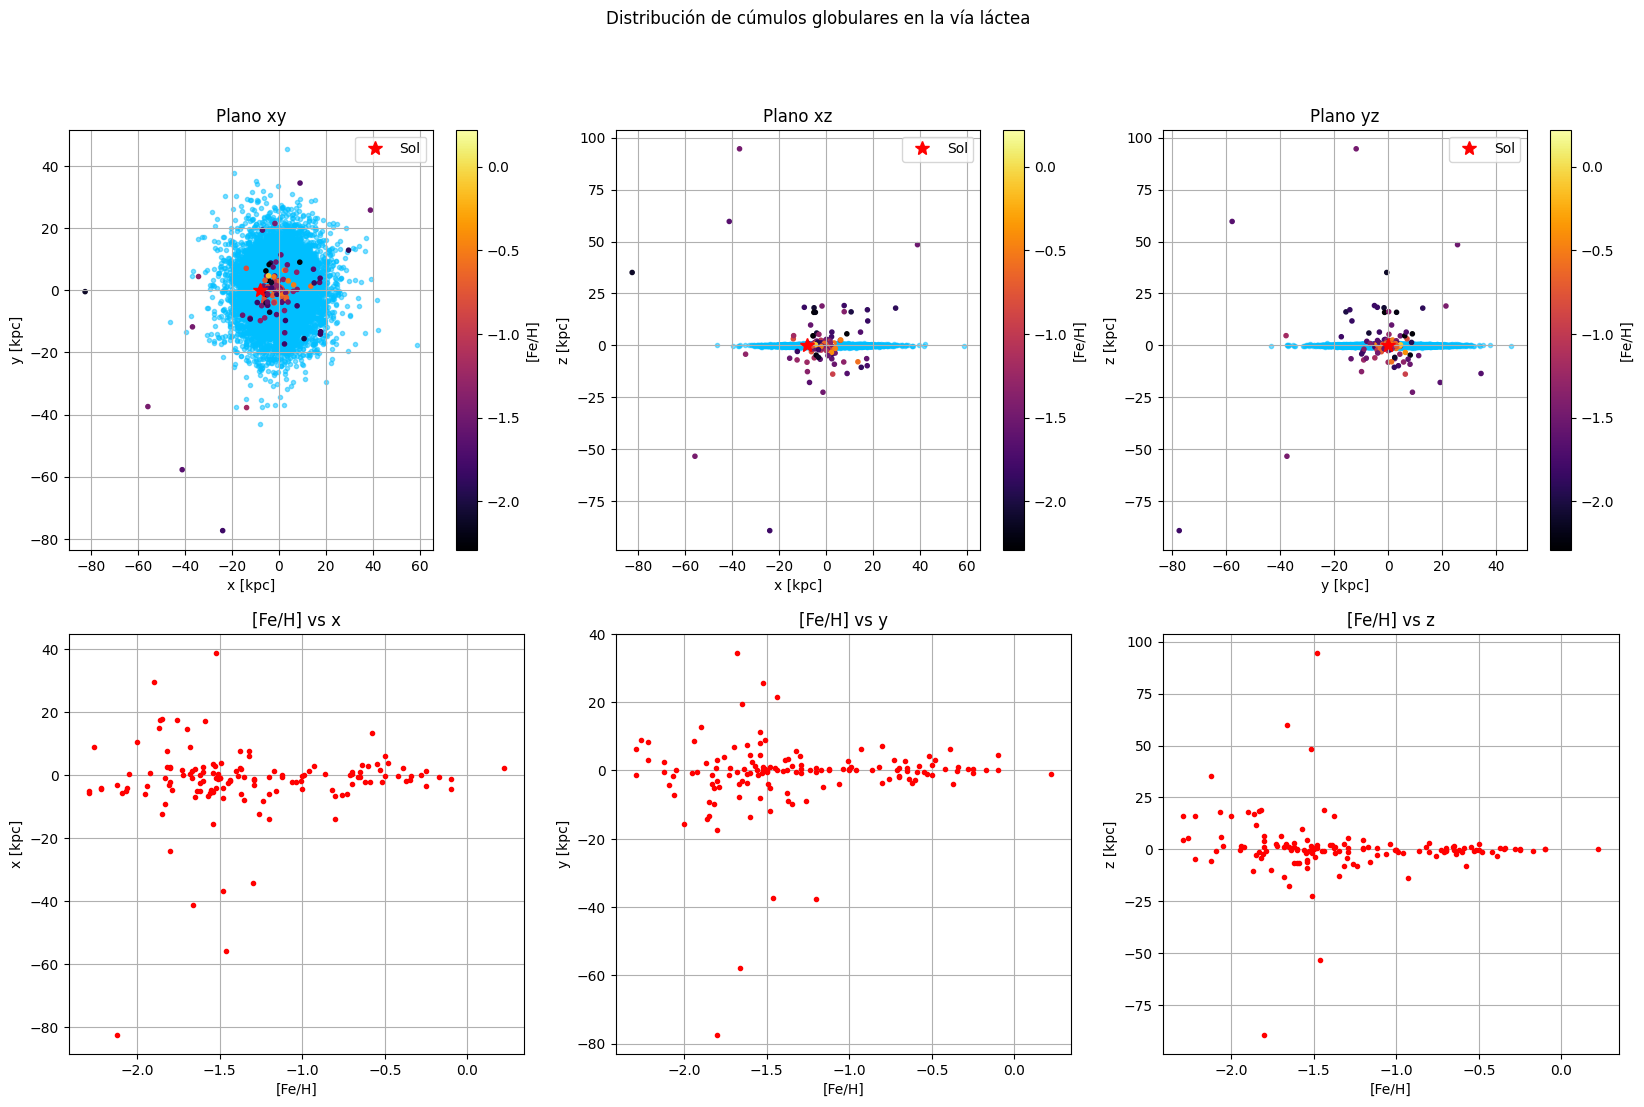

In [227]:
fig, ax = plt.subplots(2,3,figsize=(20,12))

ax[0,0].scatter(disco['x'].values,disco['y'].values,color='deepskyblue',alpha=0.5,marker='.')
ax[0,1].scatter(disco['x'].values,disco['z'].values,color='deepskyblue',alpha=0.5,marker='.')
ax[0,2].scatter(disco['y'].values,disco['z'].values,color='deepskyblue',alpha=0.5,marker='.')

sc0 = ax[0,0].scatter(cumulos['x'].values,cumulos['y'].values,marker='.',c=cumulos['Fe/H'].values,cmap='inferno',zorder=1)
ax[0,0].plot(-8,0,color='r',marker='*',linestyle='none',label='Sol',markersize=10)
fig.colorbar(sc0, ax=ax[0,0], label='[Fe/H]')
ax[0,0].set(title='Plano xy',xlabel='x [kpc]',ylabel='y [kpc]')

sc1 = ax[0,1].scatter(cumulos['x'].values,cumulos['z'].values,marker='.',c=cumulos['Fe/H'].values,cmap='inferno',zorder=1)
ax[0,1].plot(-8,0,color='r',marker='*',linestyle='none',label='Sol',markersize=10)
fig.colorbar(sc1, ax=ax[0,1], label='[Fe/H]')
ax[0,1].set(title='Plano xz',xlabel='x [kpc]',ylabel='z [kpc]')

sc2 = ax[0,2].scatter(cumulos['y'].values,cumulos['z'].values,marker='.',c=cumulos['Fe/H'].values,cmap='inferno',zorder=1)
ax[0,2].plot(0,0,color='r',marker='*',linestyle='none',label='Sol',markersize=10)
fig.colorbar(sc2, ax=ax[0,2], label='[Fe/H]')
ax[0,2].set(title='Plano yz',xlabel='y [kpc]',ylabel='z [kpc]')

ax[1,0].plot(cumulos.sort_values(['Fe/H'])['Fe/H'].values,cumulos.sort_values(['Fe/H'])['x'].values,'r.')
ax[1,1].plot(cumulos.sort_values(['Fe/H'])['Fe/H'].values,cumulos.sort_values(['Fe/H'])['y'].values,'r.')
ax[1,2].plot(cumulos.sort_values(['Fe/H'])['Fe/H'].values,cumulos.sort_values(['Fe/H'])['z'].values,'r.')

ax[1,0].set(title='[Fe/H] vs x',xlabel='[Fe/H]',ylabel='x [kpc]')
ax[1,1].set(title='[Fe/H] vs y',xlabel='[Fe/H]',ylabel='y [kpc]')
ax[1,2].set(title='[Fe/H] vs z',xlabel='[Fe/H]',ylabel='z [kpc]')

plt.suptitle('Distribución de cúmulos globulares en la vía láctea')
for a in ax[0]:
    a.grid()
    a.legend()
for a in ax[1]:
    a.grid()

plt.savefig('fig13.png')

In [229]:
center = np.array([np.mean(cumulos['x']),np.mean(cumulos['y']),np.mean(cumulos['z'])])

In [230]:
center

array([-1.63641043, -1.25098269,  1.04901052])

In [231]:
Rsun = np.array([-8,0,0])

distance = center-Rsun
distance = (distance@distance)**0.5
distance

6.569676777273531